# Mathématiques du projet SAMI

Génération des données d’entrée : positions aléatoires $(x_i, y_i)$, $i = 1,...,15$


In [65]:
import random
def positionsAléatoires(n):
    positions = []
    for i in range(n):
        x = random.randint(0, 100)
        y = random.randint(0, 100)
        positions.append((x, y))
    return positions
print(positionsAléatoires(5))

[(70, 9), (21, 76), (6, 93), (10, 66), (42, 57)]


À partir d'une matrice $C = (C_{ij})$ où $C_{ij}$ représente les distances entre la ville $i$ et la ville $j$ $(1 \leq i,j \leq n)$, il faut trouver une permutation

$$
\sigma =
\begin{pmatrix}
1 & 2 & \cdots & n \\
\sigma_1 & \sigma_2 & \cdots & \sigma_n
\end{pmatrix}
$$

qui minimise la somme des distances :

$$
C_{\sigma(1)\sigma(2)} + C_{\sigma(2)\sigma(3)} + \cdots + C_{\sigma(n-1)\sigma(n)} + C_{\sigma(n)\sigma(1)}.
$$

Autrement dit, il faut trouver un cycle hamiltonien de longueur minimale dans un graphe valué.

## Proposition : la méthode 2opt

In [66]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output
import time

# Données :
def positionsAleatoires(n):
    positions = []
    for i in range(n):
        x = random.randint(0, 100)
        y = random.randint(0, 100)
        positions.append((x, y))
    return positions

Nombre_de_points = 50
points = np.array(positionsAleatoires(Nombre_de_points))  # IMPORTANT : numpy

### Construction de la matrice des distances $A$

On considère $n$ villes repérées par leurs coordonnées dans le plan :
$$
M_i = (x_i, y_i), \quad 1 \leq i \leq n.
$$

On définit la matrice des distances $A = (A_{ij})$ par :
$$
A_{ij} = d(M_i, M_j)
$$

où $d$ est la distance euclidienne :

$$
A_{ij} = \sqrt{(x_i - x_j)^2 + (y_i - y_j)^2}.
$$

#### Remplissage de la matrice

Pour tout couple $(i,j)$ :
- on calcule la distance entre les villes $i$ et $j$,
- on stocke cette valeur dans $A_{ij}$.

#### Propriétés importantes

- $A_{ii} = 0$ (distance d'une ville à elle-même)
- $A_{ij} = A_{ji}$ (symétrie)
- $A$ est une matrice carrée de taille $n \times n$

#### Remarque

Le calcul complet nécessite $n^2$ évaluations de distance, ce qui donne une complexité en $O(n^2)$.

In [67]:
# Matrice des distances :
def matrice_des_distances(points):
    n = len(points)
    A = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            x1, y1 = points[i]
            x2, y2 = points[j]
            A[i][j] = np.sqrt((x1 - x2)**2 + (y1 - y2)**2)
    return A

A = matrice_des_distances(points)

### Calcul de la longueur d’un tour

On considère un tour représenté par une permutation des villes :
$$
\sigma = (\sigma_1, \sigma_2, \dots, \sigma_n)
$$

où $\sigma_k$ est l’indice de la $k$-ième ville visitée.

#### Définition

La longueur totale du tour est donnée par :
$$
L(\sigma) = \sum_{k=1}^{n-1} A_{\sigma_k \sigma_{k+1}} + A_{\sigma_n \sigma_1}
$$

#### Interprétation

- $A_{\sigma_k \sigma_{k+1}}$ représente la distance entre deux villes consécutives
- Le terme $A_{\sigma_n \sigma_1}$ correspond au retour à la ville de départ
- Le tour est donc un cycle fermé

#### Propriétés

- La longueur dépend de l’ordre des villes
- Si la matrice $A$ est symétrique, alors le sens du parcours ne change pas la longueur
- Cette quantité est la fonction objectif du problème du voyageur de commerce

#### Remarque

Le calcul de $L(\sigma)$ se fait en temps linéaire $O(n)$.

In [68]:
def longueur_du_tour(tour, A):
    n = len(tour)
    return sum(A[tour[i], tour[(i+1) % n]] for i in range(n))

### Opération de transformation 2-opt

On considère un tour représenté par une permutation :
$$
\sigma = (\sigma_1, \sigma_2, \dots, \sigma_n)
$$

Soient deux indices tels que $1 \leq i < k \leq n$.

#### Définition

L'opération 2-opt consiste à construire un nouveau tour $\sigma'$ en inversant le segment compris entre les positions $i$ et $k$ :

$$
\sigma' = (\sigma_1, \dots, \sigma_{i-1}, \sigma_k, \sigma_{k-1}, \dots, \sigma_i, \sigma_{k+1}, \dots, \sigma_n)
$$

#### Interprétation

- Les éléments avant $i$ sont inchangés
- Le segment $(\sigma_i, \dots, \sigma_k)$ est inversé
- Les éléments après $k$ sont inchangés

#### Effet sur le graphe

L'opération revient à :
- supprimer les arêtes $(\sigma_{i-1}, \sigma_i)$ et $(\sigma_k, \sigma_{k+1})$
- ajouter les arêtes $(\sigma_{i-1}, \sigma_k)$ et $(\sigma_i, \sigma_{k+1})$

#### Objectif

Cette transformation permet de :
- supprimer des croisements dans le tour
- potentiellement réduire la longueur totale du cycle

#### Complexité

L'opération de transformation s'effectue en temps linéaire $O(n)$.

In [69]:
def deux_opt(tour, i, k):
    """
    Inverse le segment du chemin entre les indices i et k.
    """

    # Copier le début (avant i)
    new_tour = []
    for idx in range(i):
        new_tour.append(tour[idx])

    # Ajouter le segment inversé (de k à i)
    for idx in range(k, i - 1, -1):
        new_tour.append(tour[idx])

    # Copier la fin (après k)
    for idx in range(k + 1, len(tour)):
        new_tour.append(tour[idx])

    return new_tour

### Affichage

In [70]:
def plot_tour(tour, title=""):
    pts = points[tour + [tour[0]]]  # suivre le tour
    plt.figure()
    plt.plot(pts[:,0], pts[:,1], '-o')
    plt.title(title)
    plt.show()

### Algorithme 2-opt avec visualisation (animation)

On considère un tour initial $\sigma$ et une matrice des distances $A = (A_{ij})$.

#### Principe

L’algorithme 2-opt consiste à améliorer progressivement le tour en appliquant des transformations locales jusqu’à ce qu’aucune amélioration ne soit possible.

#### Étapes

1. Initialiser un tour $\sigma$

2. Calculer sa longueur :
$$
L(\sigma)
$$

3. Répéter :

- Pour tout couple $(i,k)$ avec $1 \leq i < k \leq n$ :
  - Construire un nouveau tour $\sigma'$ en inversant le segment $[i,k]$
  - Calculer $L(\sigma')$
  - Si :
$$
L(\sigma') < L(\sigma)
$$
  alors :
  - Mettre à jour $\sigma \leftarrow \sigma'$
  - Mettre à jour $L(\sigma)$
  - Afficher le nouveau tour (animation)

4. Arrêter lorsqu’aucune amélioration n’est trouvée

#### Remarque

La visualisation permet d’observer la diminution progressive de la longueur du tour et la suppression des croisements.

#### Visualisation

À chaque amélioration :
- le nouveau tour est affiché
- la distance totale est mise à jour
- une pause permet d’observer l’évolution

#### Propriétés

- L’algorithme converge vers un minimum local
- La qualité dépend du tour initial
- La visualisation permet de suivre la suppression progressive des croisements

#### Complexité

- Une itération complète : $O(n^2)$
- Chaque transformation : $O(n)$
- Complexité globale : dépend du nombre d’améliorations

In [71]:
def deux_opt_visual(tour, A):
    best = tour
    meilleure_distance = longueur_du_tour(best, A)
    amelioration = True

    while amelioration:
        amelioration = False
        for i in range(1, len(tour)-2):
            for k in range(i+1, len(tour)-1):
                new_tour = deux_opt(best, i, k)
                new_dist = longueur_du_tour(new_tour, A)

                if new_dist < meilleure_distance:
                    best = new_tour
                    meilleure_distance = new_dist
                    amelioration = True

                    clear_output(wait=True)
                    plot_tour(best, f"Distance: {meilleure_distance:.2f}")
                    time.sleep(0.1)

        tour = best

    return best

### Phase d’exécution et visualisation

On considère le code suivant permettant d’exécuter l’algorithme 2-opt et d’afficher les résultats.

#### Étapes

1. Initialisation du tour

$$
\sigma = (0,1,2,\dots,n-1)
$$

Ce tour correspond à un parcours trivial des villes dans l’ordre de leur indice.

2. Affichage du tour initial

- Le tour est tracé graphiquement
- Il permet de visualiser la configuration de départ

3. Application de l’algorithme 2-opt

- On applique la fonction d’optimisation avec visualisation
- À chaque amélioration, le tour est mis à jour et affiché
- On obtient un tour optimisé $\sigma^*$

4. Nettoyage de l’affichage

- La dernière animation intermédiaire est supprimée
- Seul le résultat final est conservé

5. Affichage du tour final

$$
L(\sigma^*)
$$

- Le tour optimisé est tracé
- Sa longueur est affichée
- On observe la réduction de la distance totale

#### Interprétation

- Le passage de $\sigma$ à $\sigma^*$ illustre l’effet des transformations 2-opt
- Les croisements éventuels sont supprimés
- Le tour final est un minimum local

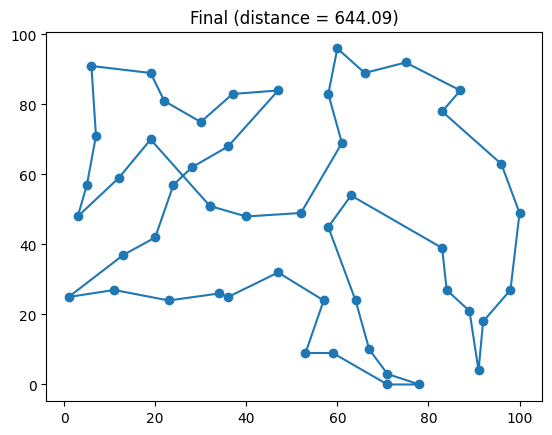

In [72]:
initial_tour = list(range(Nombre_de_points))

plot_tour(initial_tour, "Initial")
opt_tour = deux_opt_visual(initial_tour, A)

clear_output(wait=True)
plot_tour(opt_tour, f"Final (distance = {longueur_du_tour(opt_tour, A):.2f})")


On constate que le 2-opt seul converge vers une solution avec une distance finale de 644,09 qu'on peut penser raisonnablement non optimale. Dans le programme suivant on va tester l'algorithme des plus proche voisins

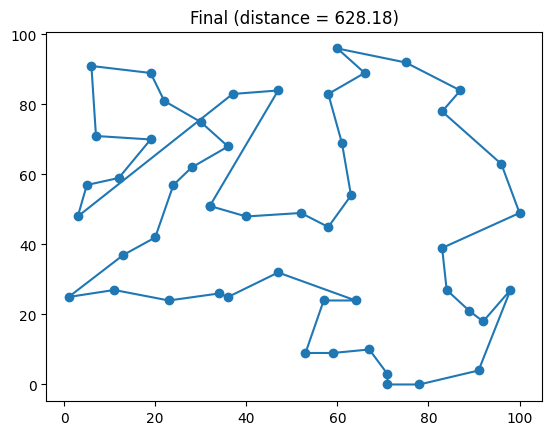

In [75]:
import math
import time
import matplotlib.pyplot as plt
from IPython.display import clear_output

def longueur_du_tour(tour, A):
    total = 0
    for i in range(len(tour) - 1):
        total += A[tour[i]][tour[i+1]]
    return total


def nearest_neighbor(points):
    n = len(points)
    visited = [False] * n
    path = []

    current = 0
    path.append(current)
    visited[current] = True

    for _ in range(n - 1):
        min_dist = float('inf')
        next_node = None

        for i in range(n):
            if not visited[i]:
                d = distance(points[current], points[i])
                if d < min_dist:
                    min_dist = d
                    next_node = i

        current = next_node
        path.append(current)
        visited[current] = True

    path.append(path[0])
    return path

def plot_tour(tour, points, title=""):
    x = [points[i][0] for i in tour]
    y = [points[i][1] for i in tour]

    plt.figure()
    plt.plot(x, y, marker='o')
    plt.title(title)
    plt.show()


# -------------------------
# EXECUTION
# -------------------------

path = nearest_neighbor(points)
plot_tour(path, points, f"Final (distance = {longueur_du_tour(path, A):.2f})")

On constate que le plus proches voisins seul converge vers une solution avec une distance finale de 628,18 qu'on peut penser raisonnablement non optimale. Dans le programme suivant on va tester l'algorithme des plus proche voisins combiné avec celui de 2-opt

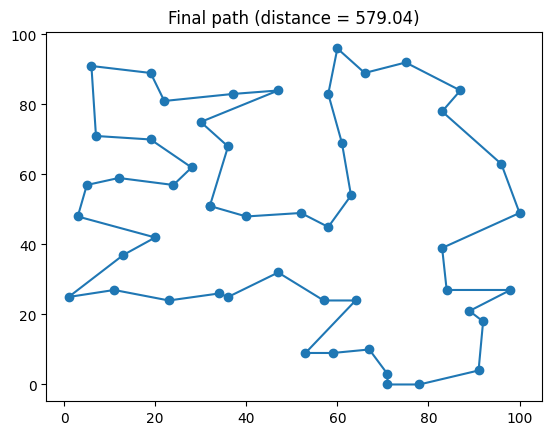

In [74]:
opt_path = two_opt_visual(path, A)

clear_output(wait=True)

plot_tour(opt_path, points, f"Final path (distance = {longueur_du_tour(opt_path, A):.2f})")

Cette fois-ci, on obtient une solution qui semble visuellement bien plus optimale que celle fournie par l’heuristique des plus proches voisins seule.
L’ajout de l’algorithme 2-opt permet en effet de corriger les défauts majeurs du chemin initial, notamment les croisements inutiles et les détours, en améliorant progressivement la trajectoire.
Ce résultat illustre l’intérêt de combiner une heuristique rapide pour obtenir une première solution avec une méthode d’optimisation locale pour l’affiner. On obtient ainsi un bon compromis entre coût de calcul et qualité de la solution.

### Conclusion

* 2-opt : $644.09$
* Plus proche voisin : $628.18$
* Plus proche voisin + 2-opt : $579.04$

Pour la suite du projet on retiendra donc la combinaison des deux heuristiques présentés ici

#### Bonus :
J'ai ajouté une vidéo dans le fichier où l'on voit le robot en action !